### Single Product Model
This is a description of the single product model with semi-lower variance:

## Model Definitions

| Symbol | Definition | Unit |
|:------:|------------|:----:|
| $W$ | Random variable of the revenue | \$ |
| $P$ | Random variable of the spot price | \$ per quintal |
| $\sigma_P$ | Standard deviation of the spot price distribution | \$ per quintal |
| $Q$ | Random variable of the produced quantity | quintal |
| $\sigma_Q$ | Standard deviation of the yield distribution | quintal |
| $\rho$ | Correlation between $P$ and $Q$ | -- |
| $f$ | Forward contract price | \$ per quintal |
| $m$ | Required farmer revenue | \$ |
| $q$ | Quantity fixed in the forward contract | quintal |

---

We consider the farmer's revenue function

$$
W = P(Q-q) + fq.
$$

Rewriting,

$$
W = PQ - qP + fq.
$$

## Objective: Lower Semi-Variance

We minimize the lower semi-variance of the revenue,

$$
\min_q \operatorname{LSV}(q)
=
\mathbb{E}\left[\left(\mathbb{E}[W]-W\right)_+^2\right],
$$

where

$$
(x)_+ = \max(x,0).
$$

### Subject to

$$
\mathbb{E}[W] \ge m,
$$

$$
q \ge 0.
$$


## We will solve numerically, using (generated) empirical data:

**Reformulation used.** Since $\bar W(q) - W_i(q) = a_i - b_i q$ is affine in $q$
(with $a_i = \overline{PQ} - P_iQ_i$ and $b_i = \bar P - P_i$), the LSV objective is convex
and piecewise-quadratic. We use the standard epigraph trick:

$$
u_i \ge a_i - b_i q, \qquad u_i \ge 0, \qquad \min \tfrac{1}{N}\sum_i u_i^2
$$

which is an exact convex QP that cvxpy solves to global optimality.

## 1. Install dependencies

In [60]:
# Run once. Comment out if cvxpy is already installed in your environment.
%pip install cvxpy numpy pandas matplotlib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

np.random.seed(0)

## 3. Load your data

Replace this synthetic block with real $(P_i, Q_i)$ pairs, e.g.

```python
df = pd.read_csv("crop_yield.csv")  # columns: P, Q
P = df["P"].to_numpy()
Q = df["Q"].to_numpy()
```

For now we simulate correlated (price, yield) scenarios to demonstrate theoretical results.

In [12]:
N = 5000         # number of scenarios
mu_P, sigma_P = 20.0, 4.0     # $ per quintal
mu_Q, sigma_Q = 10.0, 0 # quintal
rho = -0.0                 # typical negative price-yield correlation

cov = [[sigma_P**2, rho*sigma_P*sigma_Q],
       [rho*sigma_P*sigma_Q, sigma_Q**2]]

PQ = np.random.multivariate_normal([mu_P, mu_Q], cov, size=N)
P, Q = PQ[:, 0], PQ[:, 1]

df = pd.DataFrame({"P": P, "Q": Q})
df.head()

,P,Q
0,21.484929,10.0
1,22.016498,10.0
2,22.615035,10.0
3,16.546835,10.0
4,16.438687,10.0


## 4. Model parameters

In [13]:
f = 25.0            # forward contract price, $ per quintal
m = 0         # required expected revenue, $

Pbar  = P.mean()
PQbar = (P * Q).mean()
print(f"Mean price: {Pbar:.2f}, Mean revenue: {PQbar:.2f}")

a = PQbar - P * Q     # a_i
b = Pbar - P          # b_i
N_ = len(P)

Mean price: 19.94, Mean revenue: 199.43


## 5. cvxpy formulation and solve

In [14]:
q = cp.Variable(nonneg=True)
u = cp.Variable(N_, nonneg=True)

# u_i >= a_i - b_i * q  (epigraph of the max(.,0) term)
constraints = [u >= a - b * q]

# Expected revenue constraint: Wbar(q) = PQbar - q*Pbar + f*q >= m
constraints += [PQbar - q * Pbar + f * q >= m]

objective = cp.Minimize(cp.sum_squares(u) / N_)

prob = cp.Problem(objective, constraints)
prob.solve(verbose = False)  # any QP-capable solver (OSQP/ECOS/Clarabel) works

q_star = q.value
print(f"Solver status : {prob.status}")
print(f"Optimal q*    : {q_star:.4f} quintal")
print(f"LSV(q*)       : {prob.value:.4f}")
print(f"E[W](q*)      : {PQbar - q_star*Pbar + f*q_star:.2f}  (must be >= m = {m})")

Solver status : optimal
Optimal q*    : 10.0000 quintal
LSV(q*)       : 0.0000
E[W](q*)      : 250.00  (must be >= m = 0)


## 6. Cross-check with the 1-D method

Since LSV(q) is convex and piecewise-quadratic in the scalar $q$, we can verify the cvxpy
solution against a direct 1-D bounded convex minimization (`scipy.optimize.minimize_scalar`),
respecting the same feasible region.

In [6]:
def LSV(q_val):
    return np.mean(np.maximum(a - b * q_val, 0.0) ** 2)

def Variance(q):
    W = P * (Q - q) + f * q
    return np.mean((W - np.mean(W))**2)

def Wbar(q_val):
    return PQbar - q_val * Pbar + f * q_val

# Feasible interval from q >= 0 and Wbar(q) >= m
# Wbar(q) = PQbar + q*(f - Pbar) >= m  ->  solve for q depending on sign of (f - Pbar)
coef = f - Pbar
if coef > 0:
    q_lo = max(0.0, (m - PQbar) / coef)
    q_hi = max(q_lo, Q.max() * 2)   # generous upper bound
elif coef < 0:
    q_hi = max(0.0, (m - PQbar) / coef)
    q_lo = 0.0
else:
    q_lo, q_hi = 0.0, Q.max() * 2

res = minimize_scalar(LSV, bounds=(q_lo, q_hi), method="bounded")
print(f"Feasible q-range from constraints: [{q_lo:.4f}, {q_hi:.4f}]")
print(f"1-D check  q*  : {res.x:.4f}")
print(f"1-D check LSV* : {res.fun:.4f}")
print(f"Difference vs cvxpy: {abs(res.x - q_star):.6f}")

Feasible q-range from constraints: [0.0000, 32.1094]
1-D check  q*  : 5.5251
1-D check LSV* : 347.7115
Difference vs cvxpy: 0.000456


## Check against theoretical variance and LSV
The theoretical solution to the LSV minimization (without enforced constraint) with normal distributions on PQ and P is:
$$
q^* = \mathbb{E}[Q]  \left(1 + \rho \frac{\mathrm{CV}_Q}{\mathrm{CV}_P}\right)
$$



Note that this assumption does not hold. Instead the theoretical solution to the variance minimization (without enforced constraint) with any well behaved distribution is:

$$
q^* = \frac{Cov(PQ,P)}{Var(P)}
$$

For both, the tight expectation constraint optimum is given by:

$$
     q^* = \frac{m - \mathbb{E}[P] \mathbb{E}[Q] - \mathrm{Cov}(P, Q)}{f - \mathbb{E}[P]}
$$



In [12]:
def LSV_optimum():
    q_bar = Q.mean()
    p_bar = Pbar
    cv_q = Q.std(ddof=1) / q_bar
    cv_p = P.std(ddof=1) / p_bar
    rho_obs = np.corrcoef(P, Q)[0, 1]
    q_star = q_bar * (1 + rho_obs * cv_q / cv_p)

    if Wbar(q_star) < m:
        q_star = (m - PQbar) / (f - Pbar)

    return q_star

def Variance_optimum():
    cov_PQ_P = np.cov( P*Q , P )[0,1]
    var_P = np.var(P)

    q_star = cov_PQ_P / var_P

    if Wbar(q_star) < m:
        q_star = (m - PQbar) / (f - Pbar)

    return q_star


print(f"LSV optimum (analytical (normal assumption on PQ and P)) : {LSV_optimum():.4f}")
print(f" LSV value and Variance value at LSV optimum: {LSV(LSV_optimum()):.4f} {Variance(LSV_optimum()):.4f}")
print(f"Variance optimum (analytical) : {Variance_optimum():.4f}")
print(f" LSV value and Variance value at variance optimum: {LSV(Variance_optimum()):.4f} {Variance(Variance_optimum()):.4f}")
print(f"Difference LSV vs cvxpy: {abs(LSV_optimum() - q_star):.6f}")
print(f"Difference Variance vs cvxpy: {abs(Variance_optimum() - q_star):.6f}")

LSV optimum (analytical (normal assumption on PQ and P)) : 6.2282
 LSV value and Variance value at LSV optimum: 352.4547 701.6218
Variance optimum (analytical) : 6.2791
 LSV value and Variance value at variance optimum: 353.1642 701.5829
Difference LSV vs cvxpy: 0.702608
Difference Variance vs cvxpy: 0.753554


## Remark
Here we find an interesting pattern, the LSV analytical value and Variance analytical are nearly the same (and exactly under theoretical values). This is because under any symmetrical distribution of $W$, we have that LSV = 1/2 Variance. This means that $q*$ will be equal when we minimize either. When only P and Q are normal, W is not symmetrical and thus the optimal value from the LSV minimization is different than the symmetrical minimum and variance minimum. 

## 7. Visualize LSV(q) and the optimum

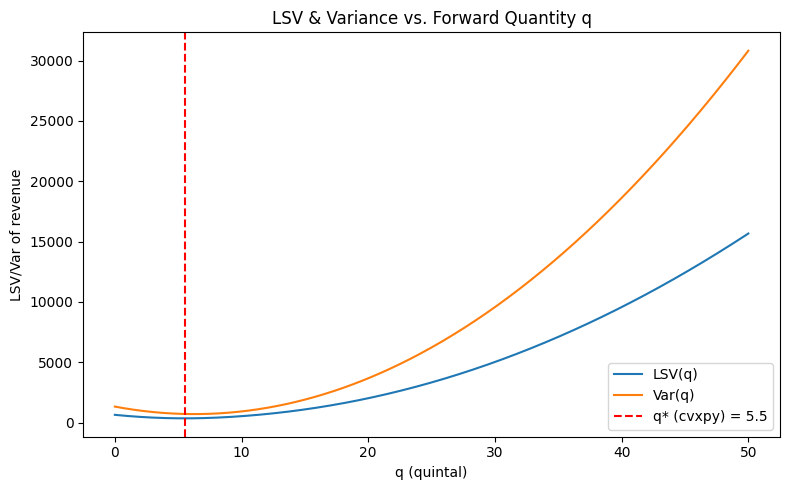

In [24]:
q_grid = np.linspace(0, 50, 400)
lsv_grid = [LSV(qv) for qv in q_grid]
var_grid = [Variance(qv) for qv in q_grid]

plt.figure(figsize=(8, 5))
plt.plot(q_grid, lsv_grid, label="LSV(q)")
plt.plot(q_grid, var_grid, label="Var(q)")
plt.axvline(q_star, color="red", linestyle="--", label=f"q* (cvxpy) = {q_star:.1f}")
plt.xlabel("q (quintal)")
plt.ylabel("LSV/Var of revenue")
plt.title("LSV & Variance vs. Forward Quantity q")
plt.legend()
plt.tight_layout()
plt.show()

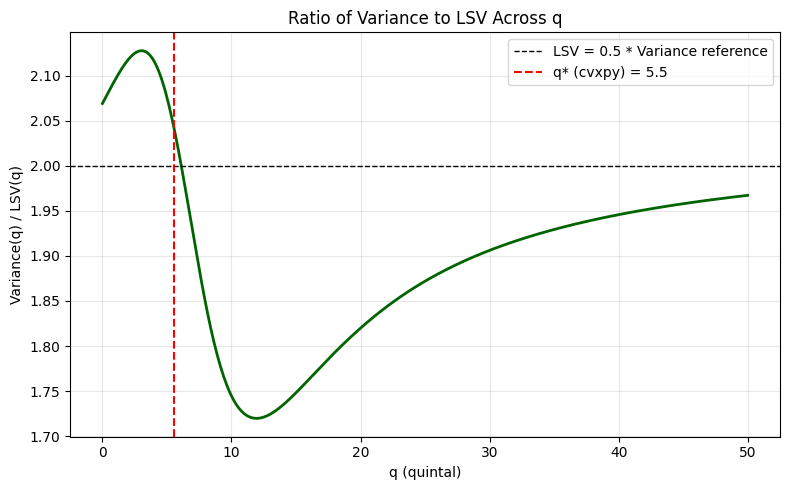

In [25]:
ratio_grid = np.asarray(var_grid) / np.asarray(lsv_grid)

plt.figure(figsize=(8, 5))
plt.plot(q_grid, ratio_grid, color="darkgreen", linewidth=2)
plt.axhline(2.0, color="black", linestyle="--", linewidth=1, label="LSV = 0.5 * Variance reference")
plt.axvline(q_star, color="red", linestyle="--", label=f"q* (cvxpy) = {q_star:.1f}")
plt.xlabel("q (quintal)")
plt.ylabel("Variance(q) / LSV(q)")
plt.title("Ratio of Variance to LSV Across q")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()